# 28 · E1o: converge first, then compare — does a linear network need synapse-specific weights?

**Where Notebook 27 left off.** Fitted cleanly, from scratch on the inner-training pairs, the linear model with a weight per synapse (`L0w`) beat L0 by **+0.076 [+0.050, +0.109]**, and all three rules chose `L0w`. The result is confounded.
* **The clean L0 was under-fitted.** It reached 0.300, against 0.421 for Notebook 25's L0, although the patience rule declared it converged. One Adam run plateaus after about 1000 steps, but a fresh learning-rate schedule escapes the plateau (Notebooks 24–25).
* **`L0w` started from that plateau and got 300–1200 more steps with a fresh schedule.** That is exactly the treatment that gave plain L0 +0.080 in Notebook 24.
* So the gain could be the synapse weights or the extra optimization.

**This notebook converges every model before comparing.** `ladder.fit_cycles` (package 0.23) repeats early-stopped fits, each restarted from the best parameters so far with a fresh warm-up / cosine schedule. A cycle is accepted only if it lowers the inner validation loss by more than `TOL`, and fitting ends at the first cycle that does not.
* **L0:** cycles from Notebook 27's clean L0 until it no longer improves.
* **`L0w`:** cycles from **that converged L0** with zero deviations. Since L0's own parameters can no longer improve validation, any further gain must come from the synapse weights.
* **`L1c`:** cycles from Notebook 27's clean `L1c`, the same treatment.

Data, folds and inner split are Notebook 27's, and every fit uses the inner-training pairs only.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 23, 0), \
    f"Notebook 28 needs closurebench >= 0.23.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BOOT, THRESHOLD, VAL_FRAC = 2000, 0.05, 0.2
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG
MODELS = ("L0", "L1c", "L0w")
PRIOR = "laptop" if MODE == "smoke" else MODE
ES = {"smoke": dict(CYCLE_STEPS=30, MAX_CYCLES=3, EVAL_EVERY=10, PATIENCE=2, TOL=1e-3),
      "laptop": dict(CYCLE_STEPS=1000, MAX_CYCLES=6, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3),
      "full": dict(CYCLE_STEPS=1500, MAX_CYCLES=8, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3)}[MODE]; globals().update(ES)

def to_np(p): return jax.tree_util.tree_map(np.asarray, dict(p))
def to_jnp(p): return jax.tree_util.tree_map(jnp.asarray, dict(p))

try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    c = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"]); LR = float(c.get("lr", 1e-2))
    P25 = dict(np.load(os.path.join(RESULTS, f"E1l_heldout_predictions{E1_TAG}.npz")))
    P27 = dict(np.load(os.path.join(RESULTS, f"E1n_heldout_predictions{E1_TAG}.npz")))
    ck27 = os.path.join(RESULTS, "e1n_ck", PRIOR)
    def _load27(f, name): return pickle.load(open(os.path.join(ck27, f"fold{f}_{name}.pkl"), "rb"))
    START = []
    for f in range(len(folds)):
        l1c = min((_load27(f, f"L1c_r{r}") for r in range(8) if os.path.exists(os.path.join(ck27, f"fold{f}_L1c_r{r}.pkl"))),
                  key=lambda d: d["es"]["val_best"])
        START.append({"L0": _load27(f, "L0")["params"], "L1c": l1c["params"]})
    d9 = os.path.join(RESULTS, f"E1e_result{E1_TAG}.json")
    DELTA = json.load(open(d9))["delta"] if os.path.exists(d9) else {}
    SOURCE = f"E1 ({E1_TAG.strip('_') or 'full'}) data and folds; starts = Notebook 27's clean fits"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 results not found (", err, ") -> CODE-PATH TEST ONLY on a synthetic worm")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=24, S=10, seed=1), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = M_.kfold_pairs(ds, 2, 0); LR = 1e-2
    P25 = P27 = None; DELTA = {"repeat": 0.01}; SOURCE = "synthetic (code path only)"; START = None
COUNT = {L: lad.trainable_count(L, st) for L in MODELS + ("L1",)}
LADDER = tuple(sorted(MODELS, key=COUNT.get))
print(f"source: {SOURCE} | {ds.N} neurons, {ds.S} stimuli | {len(folds)} folds | lr {LR} | {ES}")
print("free parameters:", COUNT, "| ladder order:", LADDER)

source: E1 (laptop) data and folds; starts = Notebook 27's clean fits | 120 neurons, 120 stimuli | 5 folds | lr 0.02 | {'CYCLE_STEPS': 1000, 'MAX_CYCLES': 6, 'EVAL_EVERY': 100, 'PATIENCE': 5, 'TOL': 0.001}
free parameters: {'L0': 126, 'L1c': 345, 'L0w': 982, 'L1': 1124} | ladder order: ('L0', 'L1c', 'L0w')


### Pre-registration (before §1)

Recorded in `results/E1o_preregistration*.json`. The outer folds, metric and bootstrap are E1's; the inner split is Notebooks 26–27's.

**Convergence by cycles** (`ladder.fit_cycles`).
* Each cycle is an early-stopped fit of at most `CYCLE_STEPS` steps (validation every `EVAL_EVERY` steps, patience `PATIENCE`), with a fresh schedule, started from the best parameters so far.
* A cycle is accepted if it lowers the inner validation loss by more than `TOL`. Fitting ends at the first rejected cycle (converged) or after `MAX_CYCLES`.
* The order is: L0 from Notebook 27's clean L0; then `L0w` from the converged L0; then `L1c` from Notebook 27's clean `L1c`.

**Rules.** Held-out FEVE, both strains, bootstrap 95 % CI.
* **ALL_CONVERGED:** every model on every fold ends with a rejected cycle before `MAX_CYCLES`.
* **RESOLUTION_HELPS_LINEAR** (primary): `L0w` − L0, CI lower bound > 0.
* **NONLINEARITY_HELPS_COMPACT:** `L1c` − L0, CI lower bound > 0.
* **CLOSED_CONVERGED:** sufficiency, necessity and v4 (every δ) on L0 → `L1c` → `L0w`.

**Reported:**
* the accepted cycles per model;
* the converged L0 against Notebook 27's clean L0 and Notebook 25's L0 (which used all training pairs);
* `L0w`'s weight change and sign flips;
* WT and unc-31 separately.

In [3]:
prereg = os.path.join(RESULTS, f"E1o_preregistration{TAG}.json")
plan = {"experiment": "E1o convergence by warm-restarted cycles: L0 (from NB27 clean L0), then L0w from converged L0, L1c (from NB27)",
        "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "source": SOURCE,
        "models": list(MODELS), "free_parameters": COUNT, "ladder_by_parameters": list(LADDER), "early_stopping": ES,
        "val_frac": VAL_FRAC, "inner_seed": "100 + fold (as Notebooks 26-27)", "lr": LR, "n_boot": N_BOOT,
        "ALL_CONVERGED": "every model, every fold: ends with a rejected cycle before MAX_CYCLES",
        "RESOLUTION_HELPS_LINEAR": "L0w - L0 held-out (both strains), CI lower bound > 0 (primary)",
        "NONLINEARITY_HELPS_COMPACT": "L1c - L0, CI lower bound > 0",
        "CLOSED_CONVERGED": "sufficiency, necessity, v4 (every delta) on L0 -> L1c -> L0w"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1o_preregistration_laptop.json


## 1 · Converge every model by cycles (checkpointed)

`laptop` mode cost per cycle: L0 ≤ 2 min, `L0w` ≤ 4 min, `L1c` ≤ 2 min, with at most 6 cycles each. Expect 2–4 h in total; most models converge in 2–4 cycles. Each converged model is saved when it finishes.

fold 0 L0 : 3 accepted cycle(s), converged | validation loss 0.9071 -> 0.8757 -> 0.8618 -> 0.8578 | 5.4 min
fold 0 L0w: 0 accepted cycle(s), converged | validation loss 0.8578 | 3.2 min
fold 0 L1c: 5 accepted cycle(s), converged | validation loss 0.9273 -> 0.9084 -> 0.8904 -> 0.8714 -> 0.8639 -> 0.8592 | 10.3 min
fold 1 L0 : 3 accepted cycle(s), converged | validation loss 0.9096 -> 0.8759 -> 0.8578 -> 0.8524 | 4.3 min
fold 1 L0w: 0 accepted cycle(s), converged | validation loss 0.8524 | 1.9 min
fold 1 L1c: 2 accepted cycle(s), converged | validation loss 0.9199 -> 0.8827 -> 0.8765 | 5.0 min
fold 2 L0 : 6 accepted cycle(s), MAX_CYCLES reached | validation loss 0.9001 -> 0.8708 -> 0.8568 -> 0.8511 -> 0.8477 -> 0.8452 -> 0.8434 | 6.4 min
fold 2 L0w: 1 accepted cycle(s), converged | validation loss 0.8434 -> 0.8424 | 7.4 min
fold 2 L1c: 6 accepted cycle(s), MAX_CYCLES reached | validation loss 0.9217 -> 0.8970 -> 0.8857 -> 0.8761 -> 0.8673 -> 0.8558 -> 0.8513 | 10.2 min
fold 3 L0 : 3 acce

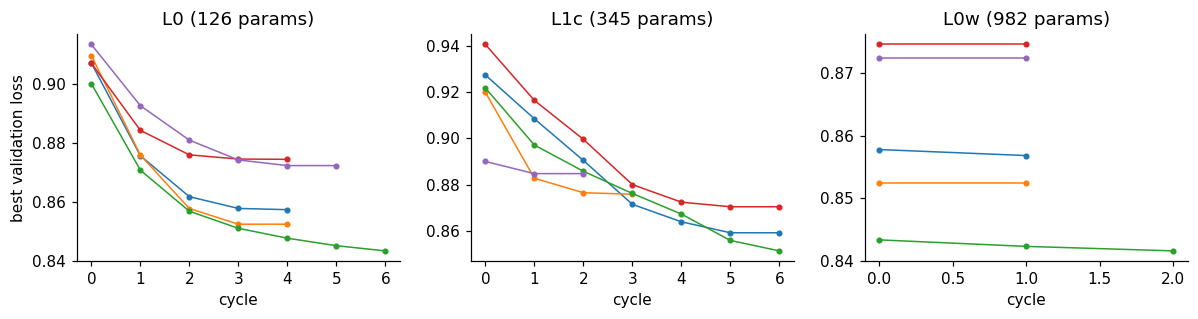

In [4]:
CK = os.path.join(RESULTS, "e1o_ck", MODE); os.makedirs(CK, exist_ok=True)
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def inner(f):
    train = split(f)[0] & ds.mask()
    u = np.random.default_rng(100 + f).random(ds.mask().shape[1:]) < VAL_FRAC
    val = train & np.broadcast_to(u, train.shape)
    return train & ~val, val
def cyc_fit(f, L, init):
    pth = os.path.join(CK, f"fold{f}_{L}.pkl")
    if os.path.exists(pth):
        d = pickle.load(open(pth, "rb")); return d["params"], d["info"]
    itr, val = inner(f); t0 = time.time()
    p, info = lad.fit_cycles(L, ds, None if init is None else to_jnp(init), itr, val, steps=CYCLE_STEPS, max_cycles=MAX_CYCLES,
                             tol=TOL, eval_every=EVAL_EVERY, patience=PATIENCE, lr=LR, st=st, cfg=cfg, seed=f)
    info = dict(info, seconds=time.time() - t0); p = to_np(p)
    pickle.dump({"params": p, "info": info}, open(pth, "wb"))
    vs = [info["cycles"][0]["val_start"]] + [c["val_best"] for c in info["cycles"] if c["accepted"]]
    print(f"fold {f} {L:3s}: {info['n_accepted']} accepted cycle(s), {'converged' if info['converged'] else 'MAX_CYCLES reached'} | "
          f"validation loss " + " -> ".join(f"{v:.4f}" for v in vs) + f" | {info['seconds'] / 60:.1f} min", flush=True)
    return p, info
if START is None:                                     # smoke without Notebook 27: clean short fits from scratch
    START = []
    for f in range(len(folds)):
        itr, val = inner(f)
        START.append({L: to_np(lad.fit(L, ds, train_mask=itr, val_mask=val, steps=CYCLE_STEPS, lr=LR, verbose=0, st=st, cfg=cfg,
                                       seed=f, eval_every=EVAL_EVERY, patience=PATIENCE)[0]) for L in ("L0", "L1c")})
FITS, INFO = [], {}
for f in range(len(folds)):
    FITS.append({})
    FITS[f]["L0"], INFO[(f, "L0")] = cyc_fit(f, "L0", START[f]["L0"])
    w0 = to_np(lad.extend_params(to_jnp(FITS[f]["L0"]), "L0w", st, jax.random.PRNGKey(0)))
    FITS[f]["L0w"], INFO[(f, "L0w")] = cyc_fit(f, "L0w", w0)
    FITS[f]["L1c"], INFO[(f, "L1c")] = cyc_fit(f, "L1c", START[f]["L1c"])
ALL_CONVERGED = all(INFO[(f, L)]["converged"] for f in range(len(folds)) for L in MODELS)
print("\naccepted cycles:", {L: [INFO[(f, L)]["n_accepted"] for f in range(len(folds))] for L in MODELS})
print("Registered rule -> ALL_CONVERGED:", ALL_CONVERGED)

def W_eff(p, L):
    q = lad.tie(st, to_jnp(p)); W = q["a_exc"] * st.S_exc + q["a_inh"] * st.S_inh + q["a_unk"] * st.S_unk
    if L == "L0w":
        W = W + q["W"] * st.chem_mask * (st.S_exc + st.S_inh + st.S_unk)
    return np.asarray(W)
MOVE = [float(np.linalg.norm(W_eff(FITS[f]["L0w"], "L0w") - W_eff(FITS[f]["L0"], "L0")) / np.linalg.norm(W_eff(FITS[f]["L0"], "L0")))
        for f in range(len(folds))]
SIGN_FLIPS = [float(np.mean(np.sign(W_eff(FITS[f]["L0w"], "L0w"))[np.asarray(st.chem_mask) > 0]
                            != np.sign(W_eff(FITS[f]["L0"], "L0"))[np.asarray(st.chem_mask) > 0])) for f in range(len(folds))]
print("L0w: relative change of the effective weights vs its L0:", np.round(MOVE, 3), "| fraction of synapses with flipped sign:", np.round(SIGN_FLIPS, 3))
fig, ax = plt.subplots(1, len(MODELS), figsize=(11, 3))
for a, L in zip(ax, MODELS):
    for f in range(len(folds)):
        cy = INFO[(f, L)]["cycles"]
        a.plot(range(len(cy) + 1), [cy[0]["val_start"]] + [c["val_best"] for c in cy], "o-", lw=1, ms=3)
    a.set_title(f"{L} ({COUNT[L]} params)"); a.set_xlabel("cycle")
ax[0].set_ylabel("best validation loss"); plt.tight_layout(); plt.show()

## 2 · Held-out comparison and E1's rules

model                     both      wt   unc31
L0                       0.428   0.381   0.529
L1c                      0.430   0.393   0.509
L0w                      0.429   0.382   0.529
L0 (NB25, all pairs)     0.421   0.374   0.520
L0 (NB27, clean)         0.300   0.292   0.317
L0w (NB27, clean)        0.376   0.350   0.431
  RESOLUTION_HELPS_LINEAR     L0w - L0 : +0.0007  95% CI [-0.0002, +0.0019]  -> False
  NONLINEARITY_HELPS_COMPACT  L1c - L0 : +0.0022  95% CI [-0.0199, +0.0273]  -> False
  converged L0 - L0 (NB25, all pairs): +0.0074  95% CI [-0.0052, +0.0218]
  converged L0 - L0 (NB27, clean): +0.1283  95% CI [+0.0805, +0.1848]

rung   gain over best shallower rung [95% CI]   needed?
L1c    +0.003 [-0.020, +0.027]               no
L0w    -0.006 [-0.026, +0.001]               no
=> deepest needed rung L_needed = L0
sufficiency L* = L0 | necessity L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}


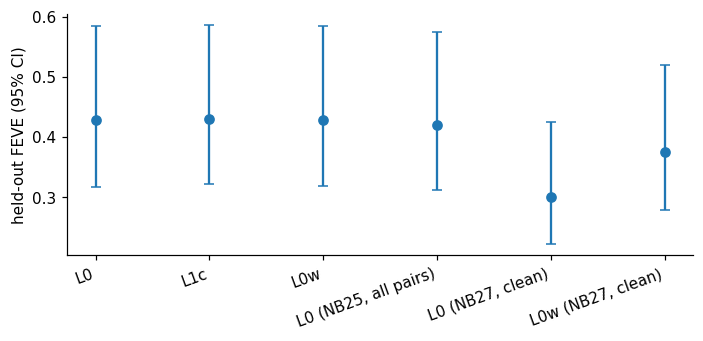

In [5]:
def full_pred(L, p):
    cols = np.arange(ds.S)
    return np.asarray(lad.predict(L, to_jnp(p), st, ds.stim, ds.strains, cfg, cols, proto=lad.proto_cols(ds, cols)))
def cv_from(L):
    out = np.zeros(ds.mean.shape)
    for f in range(len(folds)):
        msk = folds[f].reshape(folds[f].shape + (1,) * (ds.mean.ndim - 3))
        out = np.where(msk, full_pred(L, FITS[f][L]), out)
    return out
PRED = {L: cv_from(L) for L in MODELS}
if P25 is not None:
    PRED["L0 (NB25, all pairs)"] = P25["L0"]; PRED["L0 (NB27, clean)"] = P27["L0"]; PRED["L0w (NB27, clean)"] = P27["L0w"]
names = list(PRED)
point, boots = M_.bootstrap_feve(PRED, ds, names, n_boot=N_BOOT, seed=0)
per = {s: M_.bootstrap_feve(PRED, ds, names, n_boot=200, seed=0, strain=s)[0] for s in ds.strains}
print(f"{'model':22s}{'both':>8s}" + "".join(f"{s:>8s}" for s in ds.strains))
for L in names:
    print(f"{L:22s}{point[L]:8.3f}" + "".join(f"{per[s][L]:8.3f}" for s in ds.strains))
CON = {}
for name, (x, y) in {"RESOLUTION_HELPS_LINEAR": ("L0w", "L0"), "NONLINEARITY_HELPS_COMPACT": ("L1c", "L0")}.items():
    d = boots[x] - boots[y]; lo, hi = np.percentile(d, [2.5, 97.5])
    CON[name] = dict(contrast=f"{x} - {y}", point=float(point[x] - point[y]), ci=[float(lo), float(hi)], holds=bool(lo > 0))
    print(f"  {name:27s} {x:3s} - {y:3s}: {point[x] - point[y]:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  -> {CON[name]['holds']}")
if P25 is not None:
    for ref_ in ("L0 (NB25, all pairs)", "L0 (NB27, clean)"):
        d = boots["L0"] - boots[ref_]; lo, hi = np.percentile(d, [2.5, 97.5])
        print(f"  converged L0 - {ref_}: {point['L0'] - point[ref_]:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
nec = M_.necessity(point, boots, ladder=LADDER)
suff = M_.closure_decision(point, boots, ladder=LADDER, threshold=THRESHOLD, blackbox=None)
v4 = {"delta=0": M_.calibrated_closure(boots, 0.0, LADDER)["L_closed"]}
v4.update({f"delta[{k}]={d:.3f}": M_.calibrated_closure(boots, d, LADDER)["L_closed"] for k, d in DELTA.items()})
print(); print(M_.format_necessity(nec))
print(f"sufficiency L* = {suff['L_star']} | necessity L_needed = {nec['L_needed']} | v4 = {v4}")
CLOSED_CONVERGED = {"L_star": suff["L_star"], "L_needed": nec["L_needed"], "v4": v4}
fig, ax = plt.subplots(figsize=(6.5, 3.2))
mu = [point[L] for L in names]; lo = [np.percentile(boots[L], 2.5) for L in names]; hi = [np.percentile(boots[L], 97.5) for L in names]
ax.errorbar(range(len(names)), mu, yerr=[np.subtract(mu, lo), np.subtract(hi, mu)], fmt="o", capsize=3)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha="right"); ax.set_ylabel("held-out FEVE (95% CI)")
plt.tight_layout(); plt.show()

In [6]:
out = {"source": SOURCE, "early_stopping": ES, "free_parameters": COUNT, "ladder_by_parameters": list(LADDER),
       "ALL_CONVERGED": ALL_CONVERGED, "contrasts": CON, "CLOSED_CONVERGED": CLOSED_CONVERGED,
       "L0w_weight_change": MOVE, "L0w_sign_flips": SIGN_FLIPS,
       "heldout_feve": {L: float(point[L]) for L in names}, "per_strain": {s: {L: float(v) for L, v in per[s].items()} for s in per},
       "cycles": {f"{f}/{L}": INFO[(f, L)] for f in range(len(folds)) for L in MODELS}}
json.dump(out, open(os.path.join(RESULTS, f"E1o_result{TAG}.json"), "w"), indent=2, default=float)
np.savez_compressed(os.path.join(RESULTS, f"E1o_heldout_predictions{TAG}.npz"), **{L: PRED[L] for L in MODELS})
print("saved", f"E1o_result{TAG}.json and E1o_heldout_predictions{TAG}.npz")

saved E1o_result_laptop.json and E1o_heldout_predictions_laptop.npz


## Results (laptop mode, run on the M1 Mac)

**Convergence by cycles**

| model | accepted cycles on the 5 folds | validation loss, start → end | time per fold |
|---|---|---|---|
| L0 | 3, 3, **6**, 3, 4 | 0.900–0.913 → **0.843–0.875** | 4–6 min |
| `L0w` (from the converged L0) | **0, 0, 1, 0, 0** | unchanged (fold 2: 0.8434 → 0.8424) | 2–7 min |
| `L1c` | 5, 2, **6**, 5, 1 | 0.890–0.941 → 0.851–0.885 | 2.5–10 min |

* Every accepted cycle after the first lowered validation loss further. A fresh learning-rate schedule keeps finding improvements that a single early-stopped run declared impossible.
* **ALL_CONVERGED = False:** on fold 2, L0 and `L1c` used all 6 cycles; their last cycles still gained 0.002 and 0.005.
* `L0w`'s weights moved **0 %** on four folds and 2.4 % on fold 2, with no sign flips.

**Held-out FEVE (outer test pairs)**

| model | both strains | WT | unc-31 |
|---|---|---|---|
| **L0, converged** | **0.428** | 0.381 | 0.529 |
| **`L1c`, converged** | **0.430** | 0.393 | 0.509 |
| `L0w`, converged | 0.429 | 0.382 | 0.529 |
| L0, Notebook 25 (all training pairs) | 0.421 | 0.374 | 0.520 |
| L0, Notebook 27 (one early-stopped run) | 0.300 | 0.292 | 0.317 |
| `L0w`, Notebook 27 | 0.376 | 0.350 | 0.431 |

* **RESOLUTION_HELPS_LINEAR = False:** `L0w` − L0 = +0.0007 [−0.0002, +0.0019].
* **NONLINEARITY_HELPS_COMPACT = False:** `L1c` − L0 = +0.002 [−0.020, +0.027].
* **CLOSED_CONVERGED = L0** under all three rules.
* Converged L0 − Notebook 27's clean L0 = **+0.128** [+0.081, +0.185]: the whole gap was optimization. Converged L0 − Notebook 25's L0 = +0.007 [−0.005, +0.022]: the 20 % less data costs nothing.

**What this means.**
1. **Per-synapse weights add nothing to a converged linear model.** Given every chance, `L0w` declined to move its weights on 4 of 5 folds. Notebook 27's +0.076 was entirely the extra optimization it received. **The effective weights are the connectome's contact counts and signs, times three class-wide factors.**
2. **The nonlinearity neither helps nor hurts, which corrects Notebook 26.** Converged, `L1c` predicts exactly as well as L0 (0.430 vs 0.428). Notebook 26's "`L1c` is 0.096 worse than L0" compared an early-stopped `L1c` with a twice-refined L0, so it was optimization too. That claim is withdrawn. The sigmoid network, fitted to convergence, settles where the linear one does: in its linear range around rest.
3. **E1's closed level is L0, now for the right reason.** No richer description predicts better; L1c and L0w are equivalent alternatives, and E1's rules take the simplest. The prediction ceiling under single-neuron stimulation is ≈ 0.43 of the explainable variance on both strains.
4. **The method lesson is the bigger finding.** Every E1 comparison since Notebook 04 compared models at unequal distances from their optimum, so the ranking changed with optimization alone:
   * E1's "L1 ≈ L0";
   * Notebook 24's "under-fitted L0";
   * Notebook 26's "nonlinearity hurts";
   * Notebook 27's "synapse weights help".

   Only converged fits, here by warm-restarted cycles, can be compared. This applies equally to L1–L4 and the black box: their losses to L0 in Notebook 25 may be optimization too.
5. **Notebook 29 (E1p)** therefore closes E1 with the whole ladder fitted cleanly and converged, on the same inner split, and then applies E1's rules a final time:
   * L1 grown from the converged `L1c`;
   * L1s, L2, L3 and L4 grown nested from it;
   * the black box from scratch.

> **Follow-up (Notebook 29).** This notebook's three models are all *without* a slow process, and among those the reading stands: no nonlinearity and no per-synapse weights are needed. But the converged ladder shows that **a slow process is needed**: L1s, L2, L3 and L4 all beat L0 by 0.04–0.06. So the closed level is not L0 but L1s (point 3 above is superseded).

## 3 · Reading the result

| RESOLUTION_HELPS_LINEAR | NONLINEARITY_HELPS_COMPACT | reading for C2 |
|---|---|---|
| no | no | **← observed.** **E1's closed level is L0 in its strongest form.** Once L0 is converged, per-synapse weights add nothing, and Notebook 27's gain was optimization. Under single-neuron stimulation the network is linear, and its effective weights are the connectome's contact counts and signs times three class-wide factors. The program is readable from the anatomy. |
| yes | no | **Linear, with weights of its own.** The synapse weights help beyond a converged L0, and the closed level is `L0w`. The dynamics are linear and the anatomy fixes the signs and rough magnitudes (see the weight change and sign flips in §1), but each synapse's effective strength must be measured. For C2: the "software" is a linear program on the connectome, constrained but not determined by it. |
| no | yes | **A compact nonlinear network is needed** once everything is converged; the closed level moves to `L1c`. |
| yes | yes | Both help. The closed level is the richest model E1's rules accept (CLOSED_CONVERGED); a model with both would be the next rung. |

ALL_CONVERGED came out *no* only on fold 2 (L0 and `L1c` still gaining 0.002–0.005 in their 6th cycle); the contrasts are far inside their CIs, so this does not change the reading. ALL_CONVERGED = no means some model was still improving after `MAX_CYCLES`. Its score is then a lower bound, and the contrast involving it is provisional; rerun in `full` mode (8 cycles of 1500 steps).

**Limits.**
* All fits use 80 % of the training pairs, so the comparison to Notebook 25's L0 includes that handicap.
* `L0w` grows from L0. A different start could find a different, possibly better, `L0w`.
* `laptop` mode is the 120 most-sampled neurons.